In [1]:
import sys
sys.path.append('..')
from feature_selection import data_feature_selection, split_data, split_data_3way, data_feature_selection_3way

import numpy as np
import time
import os
import pandas as pd
from datetime import datetime
from numpy._core.defchararray import zfill
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import classification_report, confusion_matrix
from os import scandir
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay
from sklearn.model_selection import PredefinedSplit
from sklearn.metrics import precision_score, recall_score, f1_score


In [2]:
# Get the dataset
dataset_final = pd.read_csv("../../data/processed/DatasetMaster.csv")
dataset_final.columns


Index(['time', 'temperature_2m', 'precipitation', 'relative_humidity_2m',
       'soil_moisture_0_to_7cm', 'soil_moisture_7_to_28cm',
       'soil_moisture_28_to_100cm', 'runoff', 'et0_fao_evapotranspiration',
       'wind_speed_10m', 'wind_gusts_10m', 'alcaldia', 'tema_solicitud',
       'severidad', 'incident', 'mes', 'dia_semana', 'hora_del_dia',
       'es_fin_de_semana', 'precipitation_sum_3h',
       'soil_moisture_0_to_7cm_mean_3h', 'soil_moisture_7_to_28cm_mean_3h',
       'relative_humidity_2m_mean_3h', 'precipitation_sum_6h',
       'soil_moisture_0_to_7cm_mean_6h', 'soil_moisture_7_to_28cm_mean_6h',
       'relative_humidity_2m_mean_6h', 'precipitation_sum_12h',
       'soil_moisture_0_to_7cm_mean_12h', 'soil_moisture_7_to_28cm_mean_12h',
       'relative_humidity_2m_mean_12h', 'precipitation_sum_24h',
       'soil_moisture_0_to_7cm_mean_24h', 'soil_moisture_7_to_28cm_mean_24h',
       'relative_humidity_2m_mean_24h'],
      dtype='object')

In [3]:
# Split data function
X_train, X_test, y_train, y_test = split_data(dataset_final)

In [4]:
# Feature selection
X_train, X_test = data_feature_selection(X_train, X_test)

Original Feature Count: 48
Cleaned Feature Count:  37


In [5]:
X_train.columns

Index(['temperature_2m', 'precipitation', 'relative_humidity_2m',
       'soil_moisture_0_to_7cm', 'soil_moisture_7_to_28cm',
       'soil_moisture_28_to_100cm', 'et0_fao_evapotranspiration',
       'wind_speed_10m', 'wind_gusts_10m', 'mes', 'dia_semana', 'hora_del_dia',
       'es_fin_de_semana', 'precipitation_sum_3h',
       'relative_humidity_2m_mean_3h', 'precipitation_sum_6h',
       'relative_humidity_2m_mean_6h', 'precipitation_sum_12h',
       'relative_humidity_2m_mean_12h', 'precipitation_sum_24h',
       'relative_humidity_2m_mean_24h', 'alcaldia_ALVARO OBREGON',
       'alcaldia_AZCAPOTZALCO', 'alcaldia_BENITO JUAREZ', 'alcaldia_COYOACAN',
       'alcaldia_CUAJIMALPA DE MORELOS', 'alcaldia_CUAUHTEMOC',
       'alcaldia_GUSTAVO A. MADERO', 'alcaldia_IZTACALCO',
       'alcaldia_IZTAPALAPA', 'alcaldia_MAGDALENA CONTRERAS',
       'alcaldia_MIGUEL HIDALGO', 'alcaldia_MILPA ALTA', 'alcaldia_TLAHUAC',
       'alcaldia_TLALPAN', 'alcaldia_VENUSTIANO CARRANZA',
       'alcaldia_X

In [6]:
# Model creation
# Calculating weight to balance the classes
classes_weights = (y_train == 0).sum() / (y_train == 1).sum()

# initialize the model
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=classes_weights,
    random_state = 42,
    n_jobs = 1, # use all cores in cpu
    eval_metric = 'logloss'
)


In [7]:
# Run the model
xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [8]:
predictions_2025 = xgb_model.predict(X_test)

In [9]:
print("Classification Report using 2025 data")
print(classification_report(y_test, predictions_2025))


Classification Report using 2025 data
              precision    recall  f1-score   support

           0       0.79      0.87      0.83    105203
           1       0.71      0.58      0.64     58954

    accuracy                           0.77    164157
   macro avg       0.75      0.73      0.73    164157
weighted avg       0.76      0.77      0.76    164157



Final PR-AUC Score: 0.745


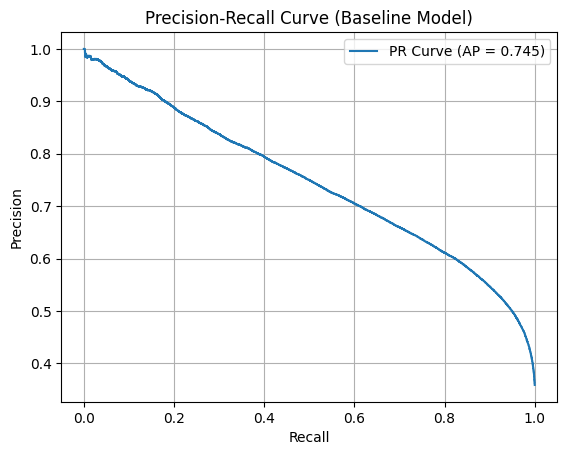

In [10]:
# Obtener probabilidades del modelo baseline
y_scores = xgb_model.predict_proba(X_test)[:, 1]

# Calcular precision-recall
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Calcular PR-AUC
ap = average_precision_score(y_test, y_scores)
print(f"Final PR-AUC Score: {ap:.3f}")

# Graficar
plt.figure()
plt.plot(recall, precision, label=f"PR Curve (AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Baseline Model)")
plt.legend()
plt.grid()

plt.show()

In [11]:
tn, fp, fn, tp = confusion_matrix(y_test, predictions_2025).ravel()

print(f"True negatives (predicted safe, was safe): {tn:,}")
print(f"False Positive (predicted incident, was safe): {fp:,} false alarms)")
print(f"False Negatives (predicted safe, was an incident) {fn:,} <- This is the danger, must be low")
print(f"True Positives (predicted incident, was an incident): {tp:,}")

True negatives (predicted safe, was safe): 91,260
False Positive (predicted incident, was safe): 13,943 false alarms)
False Negatives (predicted safe, was an incident) 24,499 <- This is the danger, must be low
True Positives (predicted incident, was an incident): 34,455


## Optimization

Splitting into 3 parts:
1. 2019-2023: training
2. 2024: validation
3. 2025: testing

In [12]:
# Split into 3 sets
X_train, X_val, X_test, y_train, y_val, y_test = split_data_3way(dataset_final)
print(f"Train Matrix (2019-2023): {X_train.shape}")
print(f"Val Matrix   (2024):      {X_val.shape}")
print(f"Test Matrix  (2025):      {X_test.shape}")

Train Matrix (2019-2023): (711299, 50)
Val Matrix   (2024):      (143012, 50)
Test Matrix  (2025):      (164157, 50)


In [13]:
# Feature selection on the sets
X_train, X_val, X_test = data_feature_selection_3way(X_train, X_val, X_test)

print(f"Train Matrix (2019-2023): {X_train.shape}")
print(f"Val Matrix   (2024):      {X_val.shape}")
print(f"Test Matrix  (2025):      {X_test.shape} ")

Train Matrix (2019-2023): (711299, 37)
Val Matrix   (2024):      (143012, 37)
Test Matrix  (2025):      (164157, 37) 


In [14]:
# Hyperparameter tuning with RandomizedSearchCV

# Merge datasets for predefined split
X_tune = pd.concat([X_train, X_val], axis=0)
y_tune = np.concatenate([y_train, y_val])

In [15]:
# PredefinedSplit Array
# -1 : Train
#  0 : Validate
split_map = np.concatenate([
    np.full(len(X_train), -1),
    np.full(len(X_val), 0)
])
fixed_validation = PredefinedSplit(test_fold=split_map)

In [16]:
# XGBoost Engine
classes_weights = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=classes_weights,
    random_state=42,
    n_jobs=-1,      # -1 : full cpu
    tree_method='hist',
    eval_metric='logloss'
)

# different parameters to try
parameters_space = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7]
}

In [ ]:
# Function to tune XGBoost hyperparameters and threshold using validation performance
def hyperparameter_tuning_xgboost(
    X_train,
    y_train,
    X_val,
    y_val,
    classes_weights,
    run_seed=42
):

    # Minimum acceptable precision while maximizing recall
    min_precision = 0.65

    # Merge train and validation only for hyperparameter search with PredefinedSplit
    X_tune = pd.concat([X_train, X_val], axis=0)
    y_tune = np.concatenate([y_train, y_val])

    # Create predefined validation split
    split_map = np.concatenate([
        np.full(len(X_train), -1),
        np.full(len(X_val), 0)
    ])

    fixed_validation = PredefinedSplit(test_fold=split_map)

    # Define XGBoost base model
    xgb_model = xgb.XGBClassifier(
        scale_pos_weight=classes_weights,
        random_state=run_seed,
        n_jobs=1,
        tree_method="hist",
        eval_metric="logloss"
    )

    # Define hyperparameter search space
    parameters_space = {
        "max_depth": [3, 5, 7, 9],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "subsample": [0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
        "min_child_weight": [1, 3, 5, 7]
    }

    # Define randomized search without refitting on train + validation
    search = RandomizedSearchCV(
        estimator=xgb_model,
        param_distributions=parameters_space,
        n_iter=15,
        scoring="average_precision",
        cv=fixed_validation,
        verbose=2,
        random_state=run_seed,
        n_jobs=1,
        refit=False
    )

    # Start execution timer
    start = time.time()

    # Fit hyperparameter search
    search.fit(X_tune, y_tune)

    # Train final champion model only on training data
    champion_model = xgb.XGBClassifier(
        scale_pos_weight=classes_weights,
        random_state=run_seed,
        n_jobs=1,
        tree_method="hist",
        eval_metric="logloss",
        **search.best_params_
    )

    champion_model.fit(X_train, y_train)

    # End execution timer
    end = time.time()

    # Convert execution time to minutes
    execution_minutes = (end - start) / 60

    # Predict validation probabilities using a model that did not train on validation
    y_val_proba = champion_model.predict_proba(X_val)[:, 1]

    # Search best threshold by maximizing recall with minimum precision constraint
    best_threshold = 0.0
    best_precision = 0.0
    best_recall = 0.0
    best_f1 = 0.0

    for current_threshold in np.arange(0.10, 0.91, 0.05):
        y_val_pred = (y_val_proba >= current_threshold).astype(int)
        current_precision = precision_score(y_val, y_val_pred, zero_division=0)
        current_recall = recall_score(y_val, y_val_pred, zero_division=0)
        current_f1 = f1_score(y_val, y_val_pred, zero_division=0)

        if current_precision >= min_precision and current_recall > best_recall:
            best_precision = current_precision
            best_recall = current_recall
            best_f1 = current_f1
            best_threshold = current_threshold

    # Fallback to best F1-score if no threshold reaches the minimum precision
    if best_threshold == 0.0:
        for current_threshold in np.arange(0.10, 0.91, 0.05):
            y_val_pred = (y_val_proba >= current_threshold).astype(int)
            current_precision = precision_score(y_val, y_val_pred, zero_division=0)
            current_recall = recall_score(y_val, y_val_pred, zero_division=0)
            current_f1 = f1_score(y_val, y_val_pred, zero_division=0)

            if current_f1 > best_f1:
                best_precision = current_precision
                best_recall = current_recall
                best_f1 = current_f1
                best_threshold = current_threshold

    # Store tuning results and selected threshold information
    tuning_results = {
        "best_params": search.best_params_,
        "best_score_pr_auc": search.best_score_,
        "best_threshold": best_threshold,
        "precision": best_precision,
        "recall": best_recall,
        "f1": best_f1
    }

    # Print tuning summary
    print(f"Tiempo de ejecución: {execution_minutes:.2f} minutos")
    print("LA ARQUITECTURA GANADORA ES:")
    for param, value in search.best_params_.items():
        print(f"-> {param}: {value}")

    print(f"-> best_threshold: {best_threshold:.2f}")
    print(f"\nMejor Score (PR-AUC) en validación: {search.best_score_:.4f}")
    print(f"Precision en validación: {best_precision:.4f}")
    print(f"Recall en validación: {best_recall:.4f}")
    print(f"F1 en validación: {best_f1:.4f}")

    # Return best model, best threshold, tuning results, and execution time
    return champion_model, best_threshold, tuning_results, execution_minutes

In [18]:
champion_model, winner_threshold, xgb_tuning_results, execution_minutes = hyperparameter_tuning_xgboost(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    classes_weights=classes_weights,
    run_seed=42
)

Fitting 1 folds for each of 15 candidates, totalling 15 fits
[CV] END colsample_bytree=0.9, learning_rate=0.01, max_depth=3, min_child_weight=7, subsample=0.8; total time=   7.3s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=7, min_child_weight=3, subsample=0.8; total time=   8.5s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=9, min_child_weight=7, subsample=0.7; total time=   9.4s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=5, min_child_weight=7, subsample=1.0; total time=   5.8s
[CV] END colsample_bytree=0.9, learning_rate=0.05, max_depth=7, min_child_weight=5, subsample=0.9; total time=   8.8s
[CV] END colsample_bytree=0.9, learning_rate=0.05, max_depth=3, min_child_weight=5, subsample=1.0; total time=   4.7s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=9, min_child_weight=7, subsample=1.0; total time=   7.2s
[CV] END colsample_bytree=0.9, learning_rate=0.2, max_depth=5, min_child_weight=7, subsample=0.9; total time=   7.1

In [ ]:
def save_run_metrics(
    model_name,
    run_id,
    y_true,
    y_proba,
    execution_time_minutes,
    threshold=0.40,
    csv_path="../results/xgboost_results.csv",
    extra_info=None
):

    # Create the results directory if it does not exist
    os.makedirs(os.path.dirname(csv_path), exist_ok=True)

    # Convert probabilities into binary predictions using the selected threshold
    y_pred = (y_proba >= threshold).astype(int)

    # Extract confusion matrix values for detailed evaluation
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Store all evaluation metrics and experiment metadata in a dictionary
    row = {
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "model": model_name,
        "run_id": run_id,
        "threshold": threshold,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, y_proba),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "execution_time_minutes": execution_time_minutes
    }

    # Add optional extra experiment information if provided
    if extra_info is not None:
        row.update(extra_info)

    # Append results to the existing CSV file if it already exists
    if os.path.exists(csv_path):
        results_df = pd.read_csv(csv_path)
        results_df = pd.concat(
            [results_df, pd.DataFrame([row])],
            ignore_index=True
        )

    # Create a new dataframe if this is the first experiment run
    else:
        results_df = pd.DataFrame([row])

    # Save the updated results dataframe to disk
    results_df.to_csv(csv_path, index=False)

    # Return the stored metrics for immediate inspection
    return row


Comparisson (2025)
              precision    recall  f1-score   support

           0       0.66      1.00      0.79    105203
           1       0.93      0.08      0.15     58954

    accuracy                           0.67    164157
   macro avg       0.80      0.54      0.47    164157
weighted avg       0.76      0.67      0.56    164157

Adjusted Confusion matrix
True negatives: 104,862
False Positive (Falsas Alarmas): 341 <- Subirán (Es el costo)
False Negatives  (EL PELIGRO): 54,245 <- DEBEN BAJAR
True Positives (SALVADOS): 4,709 <- DEBEN SUBIR

FINAL CHAMPION PR-AUC: 0.740


<Figure size 800x600 with 0 Axes>

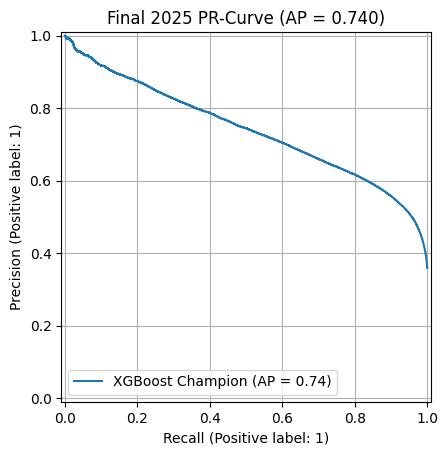

In [23]:
# Calculating probabilities for the test set
y_test_proba = champion_model.predict_proba(X_test)[:, 1]

# Predictions based on the winning threshold
y_pred_final = (y_test_proba >= winner_threshold).astype(int)

# Result metrics
print(f"\nComparisson (2025)")
print(classification_report(y_test, y_pred_final))

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()
print("Adjusted Confusion matrix")
print(f"True negatives: {tn:,}")
print(f"False Positive (Falsas Alarmas): {fp:,} <- Subirán (Es el costo)")
print(f"False Negatives  (EL PELIGRO): {fn:,} <- DEBEN BAJAR")
print(f"True Positives (SALVADOS): {tp:,} <- DEBEN SUBIR")


# PR-AUC
ap_final = average_precision_score(y_test, y_test_proba)
print(f"\nFINAL CHAMPION PR-AUC: {ap_final:.3f}")

# Graph for the RP-AUC Curve
plt.figure(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(y_test, y_test_proba, name="XGBoost Champion")
plt.title(f"Final 2025 PR-Curve (AP = {ap_final:.3f})")
plt.grid(True)
plt.show()

In [ ]:
TOTAL_RUNS = 5

for run in range(1, TOTAL_RUNS + 1):

    print("=" * 60)
    print(f"STARTING XGBOOST RUN {run}/{TOTAL_RUNS}")
    print("=" * 60)

    best_xgb_model, winner_threshold, tuning_results, execution_minutes = hyperparameter_tuning_xgboost(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    classes_weights=classes_weights,
    run_seed=42 + run
    )

    y_test_proba = best_xgb_model.predict_proba(X_test)[:, 1]

    save_run_metrics(
        model_name="XGBoost",
        run_id=run,
        y_true=y_test,
        y_proba=y_test_proba,
        execution_time_minutes=execution_minutes,
        threshold=winner_threshold,
        csv_path="../results/xgboost_results.csv"
    )

    print(f"RUN {run} COMPLETED")

STARTING XGBOOST RUN 1/5
Fitting 1 folds for each of 15 candidates, totalling 15 fits
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=5, min_child_weight=1, subsample=0.7; total time=   7.6s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=3, min_child_weight=7, subsample=1.0; total time=   4.6s
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=5, min_child_weight=1, subsample=0.9; total time=   8.0s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=9, min_child_weight=5, subsample=0.9; total time=  11.0s
[CV] END colsample_bytree=0.9, learning_rate=0.05, max_depth=7, min_child_weight=5, subsample=0.8; total time=   9.6s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, min_child_weight=5, subsample=0.7; total time=   8.5s
[CV] END colsample_bytree=0.9, learning_rate=0.2, max_depth=3, min_child_weight=5, subsample=0.8; total time=   7.3s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=7, min_child_weight=1, subsampl